In [1]:
import pandas  as  pd 
import  numpy  as  np  
import matplotlib.pyplot  as  plt 
import   seaborn  as  sns 
import warnings
warnings.filterwarnings("ignore")

In [2]:
df_row=pd.read_csv("FoodFacts.products.170k_May26.csv")
df_row.head()

,_id,product_name_en,ecoscore_grade,ingredients_text_en,categories,categories_hierarchy[0],categories_hierarchy[1],categories_hierarchy[2],categories_hierarchy[3],categories_hierarchy[4],...,packaging_hierarchy[43],packaging_hierarchy[44],packaging_hierarchy[45],packaging_hierarchy[46],packaging_hierarchy[47],packaging_hierarchy[48],packaging_hierarchy[49],packaging_hierarchy[50],packaging_hierarchy[51],packaging_hierarchy[52]
0,7896010000000.0,123,f,NaN,"Beverages and beverages preparations, Beverage...",en:beverages-and-beverages-preparations,en:plant-based-foods-and-beverages,en:beverages,en:plant-based-foods,en:beverage-preparations,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,8410390000000.0,2022,e,NaN,"Dranken en drankbereidingen,Dranken,Alcoholisc...",en:beverages-and-beverages-preparations,en:beverages,en:alcoholic-beverages,en:wines,en:red-wines,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,8901060000000.0,5050,c,NaN,Biscuits,en:snacks,en:sweet-snacks,en:biscuits-and-cakes,en:biscuits,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4004200000000.0,5.00017E+12,c,NaN,Green tapenades,en:spreads,en:salted-spreads,en:tapenades,en:green-tapenades,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5203060000000.0,5.20306E+12,d,dog,Chocolate Cookie,en:snacks,en:sweet-snacks,en:biscuits-and-cakes,en:biscuits-and-crackers,en:biscuits,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df_row.shape

(171490, 509)

In [4]:
df_row["ecoscore_grade"].value_counts()

ecoscore_grade
d         49480
b         34570
c         25989
e         24354
a         23288
f         10102
a-plus     3707
Name: count, dtype: int64

In [5]:
df_row.columns

Index(['_id', 'product_name_en', 'ecoscore_grade', 'ingredients_text_en',
       'categories', 'categories_hierarchy[0]', 'categories_hierarchy[1]',
       'categories_hierarchy[2]', 'categories_hierarchy[3]',
       'categories_hierarchy[4]',
       ...
       'packaging_hierarchy[43]', 'packaging_hierarchy[44]',
       'packaging_hierarchy[45]', 'packaging_hierarchy[46]',
       'packaging_hierarchy[47]', 'packaging_hierarchy[48]',
       'packaging_hierarchy[49]', 'packaging_hierarchy[50]',
       'packaging_hierarchy[51]', 'packaging_hierarchy[52]'],
      dtype='object', length=509)

In [6]:
df_row[["categories","ecoscore_grade"]].sample(40)

,categories,ecoscore_grade
114065,"Plantaardige levensmiddelen en dranken, Planta...",d
105023,"Snacks, Salty snacks, Appetizers, Chips and fr...",b
79045,"Plant-based foods and beverages, Beverages, Pl...",e
36734,Breakfast cereals,e
101195,en:table-salts,a
147594,"Alimentos y bebidas de origen vegetal, Aliment...",d
84418,"Plant-based foods and beverages, Plant-based f...",d
7689,"Condiments, Vinegars, Balsamic vinegars, Groce...",b
70264,"Snacks, Sweet snacks, Biscuits and cakes, Bisc...",e
142152,"Aliments et boissons à base de végétaux, Boiss...",c


In [7]:
df_row.loc[55101,"categories"]

'Dairies, Fermented foods, Fermented milk products, Spreads, Cheeses, Salted spreads, Cheese spreads'

In [8]:
df_row.isnull().sum()

_id                             0
product_name_en             58008
ecoscore_grade                  0
ingredients_text_en         97165
categories                      5
                            ...  
packaging_hierarchy[48]    171489
packaging_hierarchy[49]    171489
packaging_hierarchy[50]    171489
packaging_hierarchy[51]    171489
packaging_hierarchy[52]    171489
Length: 509, dtype: int64

In [9]:
df_row.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 171490 entries, 0 to 171489
Columns: 509 entries, _id to packaging_hierarchy[52]
dtypes: float64(2), object(507)
memory usage: 666.0+ MB


In [10]:
df_clean = df_row[['ingredients_text_en', 'ecoscore_grade', 'categories']]

In [11]:
df_clean['main_category'] = df_clean['categories'].str.split(',').str[0]
df_clean = df_clean.drop(columns=['categories'])

In [12]:
df_clean.sample(20)

,ingredients_text_en,ecoscore_grade,main_category
114858,NaN,b,Десерты
170640,NaN,d,en:parmigiano-reggiano
46120,"sugar, invert sugar, corn syrup, modified corn...",d,Snacks
147102,NaN,b,Aliments et boissons à base de végétaux
73625,"Organic pasteurized cow's milk, salt, vegetabl...",d,Dairies
2029,NaN,e,Seafood
96012,"Water, pinto beans, red bean powder, salt, por...",b,Plant-based foods and beverages
57097,"Light tuna, water, vegetable broth, sugar, sal...",e,Seafood
12655,mince beef,f,Meats and their products
53867,NaN,a,Plant-based foods and beverages


In [13]:
df_clean.isnull().sum()

ingredients_text_en    97165
ecoscore_grade             0
main_category              5
dtype: int64

In [14]:
df_clean = df_clean.dropna(subset=['ingredients_text_en', 'main_category'])


In [15]:
df_clean.isnull().sum()

ingredients_text_en    0
ecoscore_grade         0
main_category          0
dtype: int64

<Axes: xlabel='ecoscore_grade', ylabel='count'>

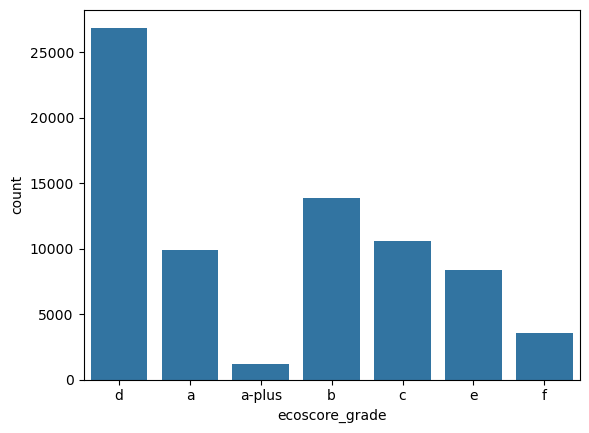

In [16]:
sns.countplot(x="ecoscore_grade", data=df_clean)

In [17]:
df_clean.sample(20)

,ingredients_text_en,ecoscore_grade,main_category
36707,Flax seeds,e,Plant-based foods and beverages
93408,"Baby swiss cheese (pasteurized part-skim milk,...",d,Dairies
4442,"Cultured milk, water, cream, whey, sodium citr...",d,Dairies
68274,"soybean oil (78%), whole eggs, apple cider vin...",d,en:mayonnaises
94181,"Cultured pasteurized milk and skim milk, whey,...",d,Dairies
45223,"Enriched wheat flour (flour, malted barley flo...",b,Plant-based foods and beverages
68037,"Tomatoes, tomato juice, calcium chloride, citr...",a,Plant-based foods and beverages
66078,Eggs 100%,c,Farming products
49261,"Φυτικά έλαια ,φυτικά λίπη , Νερό , Γαλακτωματο...",b,en:Plant-based foods and beverages
100519,"Roasted sweet potatoes, olive oil, sea salt",b,Plant-based foods and beverages


In [18]:
df_clean.shape

(74325, 3)

In [19]:
df_clean["ingredients_text_en"].duplicated().sum()


np.int64(14827)

In [20]:
df_clean.duplicated(
    subset=['ingredients_text_en', 'ecoscore_grade']
).sum()

np.int64(13957)

In [21]:
conflicts = (
    df_clean.groupby('ingredients_text_en')['ecoscore_grade']
    .nunique())

conflicts = conflicts[conflicts > 1]

len(conflicts)

769

In [22]:
df_clean = df_clean.drop_duplicates(
    subset=['ingredients_text_en', 'ecoscore_grade']
)

In [23]:
df_clean.shape

(60368, 3)

In [24]:
conflicts = (
    df_clean.groupby('ingredients_text_en')['ecoscore_grade']
    .nunique())

conflicts = conflicts[conflicts > 1]

len(conflicts)

769

In [25]:
hierarchy_cols = [
    col for col in df_row.columns
    if "ingredients_hierarchy" in col
]
df_clean["ingredient_hierarchy_text"] = (
    df_row[hierarchy_cols]
    .fillna('')
    .astype(str)
    .agg(' '.join, axis=1)
)

In [26]:
import re
import unicodedata

def clean_ingredients(text):

    if pd.isnull(text):
        return ""

    text = text.lower()

    text = unicodedata.normalize('NFKD', text)

    # remove urls
    text = re.sub(r'http\S+|www\S+', ' ', text)

    # remove phone/device garbage
    text = re.sub(r'galaxy\s\w+.*', ' ', text)

    # remove percentages
    text = re.sub(r'\d+%', ' ', text)

    # remove units like 100g, 0mg, 250ml
    text = re.sub(r'\b\d+(g|mg|ml|kg|cl|oz|lb)\b', ' ', text)

    # remove standalone pure numbers
    text = re.sub(r'\b\d+\b', ' ', text)

    # remove punctuation
    text = re.sub(r'[\(\)\[\]\{\},;:/\\\-\"]', ' ', text)

    # KEEP letters + additive codes like e330
    text = re.sub(r'[^a-zA-ZÀ-ÿ0-9\s]', ' ', text)

    # normalize spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [27]:
df_clean['ingredients_text_en'] = (
    df_clean['ingredients_text_en']
    .apply(clean_ingredients))

In [28]:
df_clean["main_category"]= (df_clean["main_category"].apply(clean_ingredients))

In [29]:
df_clean["ingredient_hierarchy_text"]= (df_clean["ingredient_hierarchy_text"].apply(clean_ingredients))

In [30]:
df_clean = df_clean[
    (df_clean['ingredients_text_en'].str.strip() != '') &
    (df_clean['main_category'].str.strip() != '') &(df_clean['ingredient_hierarchy_text'].str.strip() != '')
]


In [98]:
df_clean.isnull().sum()

ingredients_text_en          0
ecoscore_grade               0
main_category                0
ingredient_hierarchy_text    0
dtype: int64

In [31]:
df_clean.sample(10)

,ingredients_text_en,ecoscore_grade,main_category,ingredient_hierarchy_text
3693,unsweetened chocolate erythritol almonds cocoa...,e,snacks,en chocolate en e968 en almond en nut en tree ...
18920,sesame seed oil chili oil soy bean oil,c,plant based foods and beverages,en sesame oil en oil and fat en vegetable oil ...
82583,ground corn expeller pressed vegetable oil sun...,b,snacks,en corn en cereal en vegetable oil en oil and ...
49997,instant tea citric acid maltodextrin ascorbic ...,d,beverages,en instant tea en e330 en maltodextrin en e300...
100204,water sugar pineapple juice tomatoes white vin...,a,condiments,en water en sugar en added sugar en disacchari...
76336,water gluten free wheat starch dried skimmed m...,a-plus,plant based foods and beverages,en water en gluten free wheat starch en skimme...
14669,potato vegetable oil consomme powder chicken b...,b,plant based foods and beverages,en potato en vegetable en root vegetable en tu...
20492,milk skin mi sugar high fructose corn syrup co...,e,beverages,en milk en dairy en skin mi sugar en high fruc...
4138,pasteurized part skim milk salt cheese culture...,d,dairies,en pasteurized semi skimmed milk en dairy en m...
32368,milk cream sugar egg yolks whey powder dextros...,d,dairies,en milk en dairy en cream en sugar en added su...


In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95,stop_words="english"
)


In [33]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y = le.fit_transform(df_clean['ecoscore_grade'])

In [34]:
df_clean.isnull().sum()

ingredients_text_en          0
ecoscore_grade               0
main_category                0
ingredient_hierarchy_text    0
dtype: int64

In [70]:
X=df_clean.drop(columns=["ecoscore_grade"])

In [96]:
X

,ingredients_text_en,main_category,ingredient_hierarchy_text
4,dog,chocolate cookie,en dog
6,green asparagus water salt acidity regulator s...,plant based foods and beverages,en green asparagus en vegetable en shoot veget...
7,single cream pasteurised egg yolk sugar milk p...,dairies,en single cream en dairy en cream en pasteuris...
8,peach white sugar brown sugar concentrated lem...,plant based foods and beverages,en peach en fruit en prunus species fruit en w...
10,honey,breakfasts,en honey en added sugar
...,...,...,...
171352,es snack de patata con sabor a nata agriaya ce...,potato crisps,en es snack de patata con sabor a nata agriaya...
171363,in shell peanuts,alimente s i ba uturi pe baza de plante,ro arahide i n coaja
171425,organic dulse flakes,seaweeds and their products,en dulse en algae
171467,green tea,green teas,en green tea en plant en tea


In [72]:
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95
)

preprocess = ColumnTransformer(
    transformers=[
        ('tfidf_ing', tfidf, 'ingredients_text_en'),
        ('tfidf_cat', tfidf, 'main_category'),
        ('tfidf_hier', tfidf, 'ingredient_hierarchy_text')
    ],
    remainder='drop'   # or 'passthrough' if you want to keep numeric columns
)

X_text = preprocess.fit_transform(df_clean)


In [38]:

# labels
y = le.fit_transform(df_clean['ecoscore_grade'])

In [73]:
X_text.shape

(59711, 21850)

In [97]:
X_train

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 5904428 stored elements and shape (47768, 21850)>

In [74]:
y.shape

(59711,)

In [75]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y)

In [76]:
print("X_train shape", X_train.shape)
print("X_test shape", X_test.shape)
print("y_train shape", y_train.shape)
print("y_test  shape", y_test.shape)


X_train shape (47768, 21850)
X_test shape (11943, 21850)
y_train shape (47768,)
y_test  shape (11943,)


In [77]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [78]:
y_pred = model.predict(X_test)

In [79]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.18      0.43      0.25       216
           1       0.64      0.62      0.63      1496
           2       0.72      0.68      0.70      2312
           3       0.60      0.62      0.61      1872
           4       0.86      0.73      0.79      4114
           5       0.59      0.70      0.64      1391
           6       0.56      0.74      0.64       542

    accuracy                           0.68     11943
   macro avg       0.59      0.65      0.61     11943
weighted avg       0.71      0.68      0.69     11943



In [80]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(C=0.1,
    class_weight='balanced'
)

svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)


In [81]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.17      0.26      0.21       216
           1       0.66      0.68      0.67      1496
           2       0.72      0.72      0.72      2312
           3       0.66      0.58      0.62      1872
           4       0.83      0.78      0.81      4114
           5       0.60      0.69      0.64      1391
           6       0.60      0.71      0.65       542

    accuracy                           0.70     11943
   macro avg       0.61      0.63      0.62     11943
weighted avg       0.71      0.70      0.71     11943



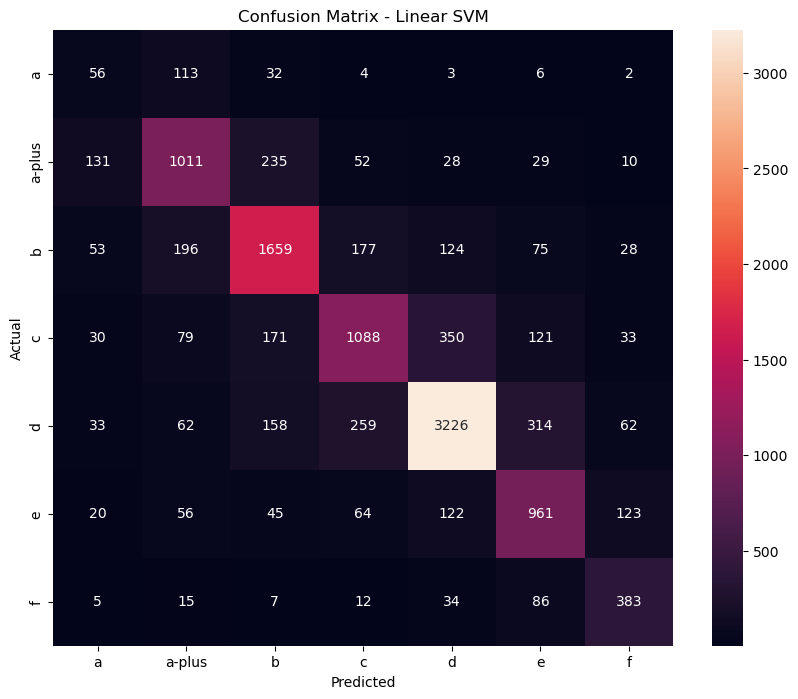

In [83]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(10,8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Linear SVM")

plt.show()

In [50]:
pd.Series(y_test).value_counts()

4    4114
2    2312
3    1872
0    1496
5    1391
6     542
1     216
Name: count, dtype: int64

In [84]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(
    n_components=300,
    random_state=42
)

X_svd = svd.fit_transform(X_text)

In [85]:
from sklearn.model_selection import train_test_split

X_train_svd, X_test_svd, y_train, y_test = train_test_split(
    X_svd,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [86]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

In [87]:
rf_model.fit(X_train_svd, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=20, n_estimators=200,
                       n_jobs=-1, random_state=42)

In [88]:
y_pred_rf = rf_model.predict(X_test_svd)

In [89]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))



              precision    recall  f1-score   support

           0       0.24      0.15      0.18       216
           1       0.62      0.67      0.64      1496
           2       0.63      0.75      0.69      2312
           3       0.69      0.56      0.61      1872
           4       0.80      0.80      0.80      4114
           5       0.63      0.65      0.64      1391
           6       0.72      0.51      0.59       542

    accuracy                           0.69     11943
   macro avg       0.62      0.58      0.59     11943
weighted avg       0.69      0.69      0.69     11943



In [57]:
df_row["ecoscore_grade"].value_counts()

ecoscore_grade
d         49480
b         34570
c         25989
e         24354
a         23288
f         10102
a-plus     3707
Name: count, dtype: int64

In [58]:
df_clean.shape

(59711, 4)

In [94]:
X_test.toarray()[:5]


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [90]:
df_clean.head()

,ingredients_text_en,ecoscore_grade,main_category,ingredient_hierarchy_text
4,dog,4,chocolate cookie,en dog
6,green asparagus water salt acidity regulator s...,1,plant based foods and beverages,en green asparagus en vegetable en shoot veget...
7,single cream pasteurised egg yolk sugar milk p...,0,dairies,en single cream en dairy en cream en pasteuris...
8,peach white sugar brown sugar concentrated lem...,0,plant based foods and beverages,en peach en fruit en prunus species fruit en w...
10,honey,2,breakfasts,en honey en added sugar


In [60]:
df_row.isnull().sum()

_id                             0
product_name_en             58008
ecoscore_grade                  0
ingredients_text_en         97165
categories                      5
                            ...  
packaging_hierarchy[48]    171489
packaging_hierarchy[49]    171489
packaging_hierarchy[50]    171489
packaging_hierarchy[51]    171489
packaging_hierarchy[52]    171489
Length: 509, dtype: int64

In [61]:
df1=df_row.dropna()

In [62]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import LinearSVC

param_grid = {
    'C': [0.01, 0.1, 1, 10]
}

grid = GridSearchCV(
    LinearSVC(class_weight='balanced'),
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=LinearSVC(class_weight='balanced'), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10]}, scoring='accuracy')

In [63]:
print(grid.best_params_)
print(grid.best_score_)

{'C': 0.1}
0.6912995978803057


In [64]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    objective='multi:softprob',
    num_class=7,
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=42
)

In [65]:
xgb_model.fit(X_train_svd, y_train)
y_pred_xgb = xgb_model.predict(X_test_svd)

In [66]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.69      0.68      0.69      1496
           1       0.31      0.06      0.09       216
           2       0.67      0.77      0.72      2312
           3       0.71      0.57      0.63      1872
           4       0.78      0.84      0.81      4114
           5       0.63      0.65      0.64      1391
           6       0.75      0.53      0.62       542

    accuracy                           0.71     11943
   macro avg       0.65      0.59      0.60     11943
weighted avg       0.71      0.71      0.71     11943

